[*********************100%***********************]  1 of 1 completed


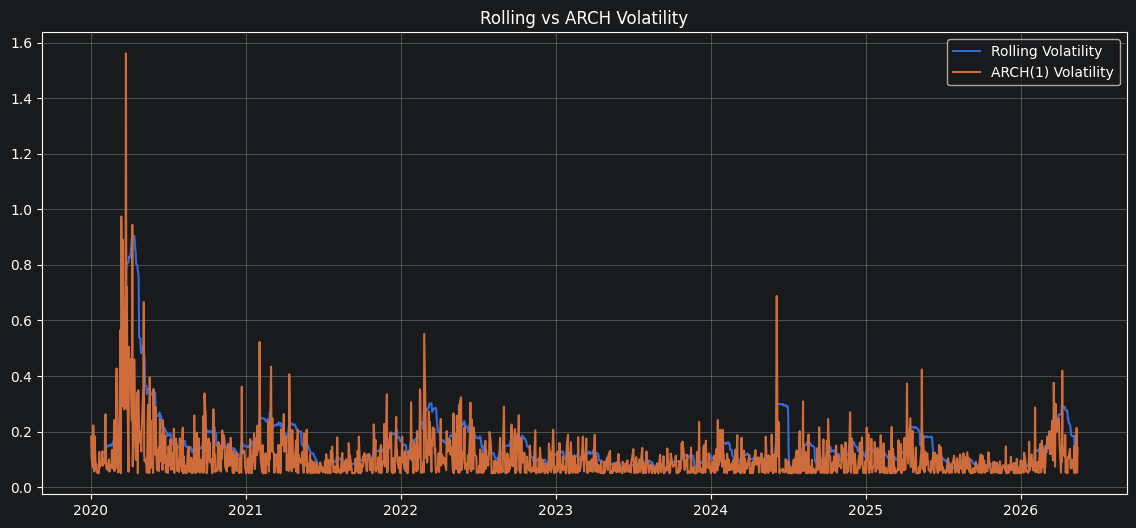

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Download data
df = yf.download("^NSEI", start="2020-01-01")

# Log returns
df["log_return"] = np.log(df["Close"] / df["Close"].shift(1))

returns = df["log_return"].dropna()

# ARCH(1) parameters
omega = 0.00001
alpha = 0.5

# Initialize variance
arch_var = [returns.var()]

# Recursive ARCH calculation
for r in returns[:-1]:

    new_var = (
        omega
        + alpha * r**2
    )

    arch_var.append(new_var)

# Convert to annualized volatility
arch_vol = np.sqrt(arch_var) * np.sqrt(252)

# Align dataframe
df = df.iloc[1:].copy()

df["arch_vol"] = arch_vol

# Rolling volatility comparison
df["rolling_vol"] = (
    returns.rolling(20).std() * np.sqrt(252)
)

# Plot
plt.figure(figsize=(14,6))

plt.plot(df.index, df["rolling_vol"], label="Rolling Volatility")
plt.plot(df.index, df["arch_vol"], label="ARCH(1) Volatility")

plt.title("Rolling vs ARCH Volatility")
plt.legend()
plt.grid(True)

plt.show()